# Chapter 15 · MLflow experiment tracking on a remote server: walkthrough

Companion to `notes/15_mlflow_tracking_with_dagshub.html` (video 03:42:34 – 04:05:17).

In the video the instructor runs `demo.py` three times with different `alpha` / `l1_ratio` values, with **DagsHub** as the remote MLflow server, then compares the runs in the MLflow UI.
DagsHub needs your own account, so this notebook starts a **local MLflow tracking server** in its place. That's exactly what DagsHub hosts for you: an MLflow server reached over HTTP. The script is the same either way; only the address changes.

| Step | What happens |
|---|---|
| 1 | start `mlflow server` (stands in for DagsHub) |
| 2 | run `python demo.py`, then `demo.py 0.3 0.6`, then `demo.py 0.7 0.6` |
| 3 | compare the runs and pick the best (lowest RMSE/MAE, highest R²) |
| 4 | beyond the video: model registry → `@champion` alias → load it |
| 5 | beyond the video: **serve the champion model as a REST API** and call it |
| 6 | delete a run, then switch to DagsHub |

In [1]:
import os, sys, time, json, shutil, subprocess, urllib.request, warnings
import certifi
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

HERE = os.getcwd()
assert os.path.exists("demo.py"), "run this notebook from the ch15_mlflow_dagshub folder"
BIN = os.path.dirname(sys.executable)                 # the .venv's bin folder (mlflow, python)
PORT, SERVE_PORT = 5057, 5058
TRACKING_URI = f"http://127.0.0.1:{PORT}"

# fresh start: remove tracking data from earlier runs of this notebook
for path in ("mlflow.db",):
    if os.path.exists(path): os.remove(path)
for folder in ("mlartifacts", "mlruns"):
    shutil.rmtree(folder, ignore_errors=True)

def wait_for(url, timeout=60):
    for _ in range(timeout * 2):
        try:
            with urllib.request.urlopen(url, timeout=1) as r:
                if r.status == 200: return True
        except Exception:
            time.sleep(0.5)
    raise TimeoutError(url)
print("python:", sys.executable)

python: /Users/hemanthreddy/Desktop/data_science/MLOps/projects/.venv/bin/python3.13


## 1 · Start the tracking server  (plays the role of DagsHub)

`mlflow server` stores run data in a database (`mlflow.db`) and model files under `mlartifacts/`, and serves the UI and API over HTTP.

In [2]:
server_log = open("tracking_server.log", "w")
server = subprocess.Popen(
    [f"{BIN}/mlflow", "server", "--backend-store-uri", "sqlite:///mlflow.db",
     "--host", "127.0.0.1", "--port", str(PORT)],
    stdout=server_log, stderr=subprocess.STDOUT,
)
wait_for(f"{TRACKING_URI}/health", timeout=90)
print("tracking server is up at", TRACKING_URI, "(pid", server.pid, ")")

tracking server is up at http://127.0.0.1:5057 (pid 20498 )


## 2 · The script: `demo.py`  (video 03:43 – 03:57)

The instructor's structure: load the wine CSV (semicolon-separated) → train/test split → read `alpha` and `l1_ratio` from `sys.argv` (default 0.5) → inside `with mlflow.start_run():` train, evaluate, **`log_param`**, **`log_metric`**, and log/register the model.

In [3]:
print(open("demo.py").read())

"""ElasticNet on the red-wine-quality data, tracked with MLflow.

Usage:
    python demo.py [alpha] [l1_ratio]          # defaults: 0.5 0.5

Where the runs go (checked in this order):
    1. DagsHub   - set DAGSHUB_REPO_OWNER and DAGSHUB_REPO_NAME (log in once with `dagshub login`)
    2. Any MLflow tracking server - set MLFLOW_TRACKING_URI, e.g. http://127.0.0.1:5000
    3. Otherwise - a local ./mlruns folder (model registration is skipped there)
"""
import logging
import os
import sys
import warnings
from urllib.parse import urlparse

import certifi
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

os.environ.setdefault("SSL_CERT_FILE", certifi.where())   # macOS python.org builds need this for HTTPS
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")

import mlflow  # noqa: E402
import mlflow.sklearn  # noqa: E402
fr

## 3 · Run three experiments  (video 03:59 – 04:01)

The same commands as the video, with `MLFLOW_TRACKING_URI` pointing at our server. With DagsHub you'd set `DAGSHUB_REPO_OWNER` / `DAGSHUB_REPO_NAME` instead.

In [4]:
env = {**os.environ, "MLFLOW_TRACKING_URI": TRACKING_URI, "PATH": BIN + os.pathsep + os.environ["PATH"]}
env.pop("DAGSHUB_REPO_OWNER", None); env.pop("DAGSHUB_REPO_NAME", None)

for args in ([], ["0.3", "0.6"], ["0.7", "0.6"]):
    cmd = ["python", "demo.py", *args]
    print("$", " ".join(cmd))
    out = subprocess.run(cmd, env=env, capture_output=True, text=True)
    print(out.stdout)
    if out.returncode != 0:
        print(out.stderr[-2000:]); raise SystemExit("demo.py failed")

$ python demo.py


ElasticNet (alpha=0.5, l1_ratio=0.5)
  RMSE: 0.7932
  MAE:  0.6272
  R2:   0.1086
  run id: dd686081312342bfa8ea661115295f6f
  tracked at: http://127.0.0.1:5057
🏃 View run alpha=0.5_l1=0.5 at: http://127.0.0.1:5057/#/experiments/1/runs/dd686081312342bfa8ea661115295f6f
🧪 View experiment at: http://127.0.0.1:5057/#/experiments/1

$ python demo.py 0.3 0.6


ElasticNet (alpha=0.3, l1_ratio=0.6)
  RMSE: 0.7661
  MAE:  0.5984
  R2:   0.1684
  run id: 603bf9a1a7244969b7db79087efff030
  tracked at: http://127.0.0.1:5057
🏃 View run alpha=0.3_l1=0.6 at: http://127.0.0.1:5057/#/experiments/1/runs/603bf9a1a7244969b7db79087efff030
🧪 View experiment at: http://127.0.0.1:5057/#/experiments/1

$ python demo.py 0.7 0.6


ElasticNet (alpha=0.7, l1_ratio=0.6)
  RMSE: 0.8322
  MAE:  0.6662
  R2:   0.0188
  run id: 4a2105380d7346f58e6fdfc6e435c8ce
  tracked at: http://127.0.0.1:5057
🏃 View run alpha=0.7_l1=0.6 at: http://127.0.0.1:5057/#/experiments/1/runs/4a2105380d7346f58e6fdfc6e435c8ce
🧪 View experiment at: http://127.0.0.1:5057/#/experiments/1



## 4 · Compare the runs and pick the best  (video 04:01 – 04:03)

For a regression model, **RMSE and MAE should be low** and **R² should be high**. The instructor compares the runs on a parallel coordinates plot and picks the line that is low on RMSE/MAE and high on R².

In [5]:
import mlflow
from mlflow import MlflowClient
mlflow.set_tracking_uri(TRACKING_URI)

runs = mlflow.search_runs(experiment_names=["wine-quality-elasticnet"], order_by=["metrics.rmse ASC"])
table = runs[["tags.mlflow.runName", "params.alpha", "params.l1_ratio",
              "metrics.rmse", "metrics.mae", "metrics.r2", "run_id"]].copy()
table.columns = ["run", "alpha", "l1_ratio", "rmse", "mae", "r2", "run_id"]
table["run_id"] = table["run_id"].str[:8]
table.round(4)

,run,alpha,l1_ratio,rmse,mae,r2,run_id
0,alpha=0.3_l1=0.6,0.3,0.6,0.7661,0.5984,0.1684,603bf9a1
1,alpha=0.5_l1=0.5,0.5,0.5,0.7932,0.6272,0.1086,dd686081
2,alpha=0.7_l1=0.6,0.7,0.6,0.8322,0.6662,0.0188,4a210538


In [6]:
best = table.iloc[0]
agree = (table.rmse.idxmin() == table.mae.idxmin() == table.r2.idxmax())
print(f"best run: {best.run}  (RMSE {best.rmse:.4f}, MAE {best.mae:.4f}, R² {best.r2:.4f})")
print("all three metrics agree on the winner:", agree)

best run: alpha=0.3_l1=0.6  (RMSE 0.7661, MAE 0.5984, R² 0.1684)
all three metrics agree on the winner: True


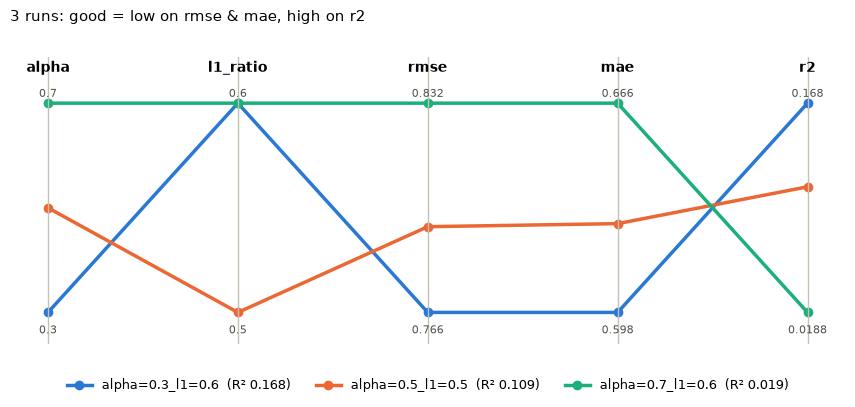

In [7]:
cols = ["alpha", "l1_ratio", "rmse", "mae", "r2"]
df = table[cols].astype(float)
lo, hi = df.min(), df.max()
span = (hi - lo).replace(0, 1)
norm = (df - lo) / span

palette = ["#2a78d6", "#eb6834", "#1baf7a"]
fig, ax = plt.subplots(figsize=(9, 4.2))
for (idx, row), color in zip(norm.iterrows(), palette):
    ax.plot(range(len(cols)), row.values, color=color, linewidth=2.5, marker="o",
            label=f"{table.loc[idx, 'run']}  (R² {table.loc[idx, 'r2']:.3f})")
for i, c in enumerate(cols):
    ax.axvline(i, color="#c3c2b7", linewidth=1)
    ax.text(i, 1.15, c, ha="center", fontsize=10, fontweight="bold")
    ax.text(i, 1.03, f"{hi[c]:.3g}", ha="center", fontsize=8, color="#52514e")
    ax.text(i, -0.10, f"{lo[c]:.3g}", ha="center", fontsize=8, color="#52514e")
ax.set_xticks([]); ax.set_yticks([]); ax.set_ylim(-0.15, 1.22)
for s in ax.spines.values(): s.set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False, fontsize=9)
ax.set_title("3 runs: good = low on rmse & mae, high on r2", loc="left", fontsize=10.5, pad=26)
plt.tight_layout(); plt.show()

## 5 · Beyond the video: the model registry

Because we logged to a **server**, `demo.py` also **registered** each model as a new version of `ElasticnetWineModel` (the `urlparse` check in the script). Next: find the version that came from the best run, mark it with the alias **`champion`**, and load it by that name. This is how production code refers to "the current best model" without hard-coding run IDs.

In [8]:
client = MlflowClient()
versions = client.search_model_versions("name='ElasticnetWineModel'")
reg = pd.DataFrame([{"version": int(v.version), "run_id": v.run_id[:8], "status": v.status} for v in versions]).sort_values("version")
reg = reg.merge(table[["run_id", "run", "rmse", "r2"]], on="run_id")
reg

,version,run_id,status,run,rmse,r2
0,1,dd686081,READY,alpha=0.5_l1=0.5,0.793164,0.108626
1,2,603bf9a1,READY,alpha=0.3_l1=0.6,0.766103,0.168413
2,3,4a210538,READY,alpha=0.7_l1=0.6,0.832152,0.018842


In [9]:
best_full_run_id = runs.iloc[0].run_id
champion = next(v for v in versions if v.run_id == best_full_run_id)
client.set_registered_model_alias("ElasticnetWineModel", "champion", champion.version)
print(f"alias 'champion' → version {champion.version}")

model = mlflow.pyfunc.load_model("models:/ElasticnetWineModel@champion")
wine = pd.read_csv("https://raw.githubusercontent.com/mlflow/mlflow/master/tests/datasets/winequality-red.csv", sep=";")
sample = wine.drop(columns="quality").sample(5, random_state=7)
pd.DataFrame({"predicted quality": model.predict(sample).ravel().round(2),
              "actual quality": wine.loc[sample.index, "quality"].values})

alias 'champion' → version 2


,predicted quality,actual quality
0,5.54,6
1,5.56,6
2,5.75,6
3,5.52,5
4,5.78,6


## 6 · Beyond the video: serve the champion as a REST API

`mlflow models serve` wraps the registered model in a web server with a `/invocations` endpoint, which is a first step towards deployment.
`--env-manager local` reuses this environment instead of building a new one.

In [10]:
serve_log = open("model_server.log", "w")
serving = subprocess.Popen(
    [f"{BIN}/mlflow", "models", "serve", "-m", "models:/ElasticnetWineModel@champion",
     "--host", "127.0.0.1", "--port", str(SERVE_PORT), "--env-manager", "local"],
    env=env, stdout=serve_log, stderr=subprocess.STDOUT,
)
wait_for(f"http://127.0.0.1:{SERVE_PORT}/ping", timeout=120)
print("model server is up: POST http://127.0.0.1:%d/invocations" % SERVE_PORT)

model server is up: POST http://127.0.0.1:5058/invocations


In [11]:
payload = {"dataframe_split": json.loads(sample.head(3).to_json(orient="split", index=False))}
req = urllib.request.Request(f"http://127.0.0.1:{SERVE_PORT}/invocations",
                             data=json.dumps(payload).encode(), headers={"Content-Type": "application/json"})
with urllib.request.urlopen(req) as r:
    answer = json.loads(r.read())
print("request :", json.dumps(payload)[:160], "…")
print("response:", answer)

request : {"dataframe_split": {"columns": ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide …
response: {'predictions': [5.543092389290865, 5.555592932038891, 5.750257861415466]}


The same call from a terminal:

```bash
curl -X POST http://127.0.0.1:5058/invocations -H "Content-Type: application/json" \
  -d '{"dataframe_split": {"columns": ["fixed acidity", …, "alcohol"], "data": [[7.4, 0.7, …, 9.4]]}}'
```

In [12]:
serving.terminate(); serving.wait(timeout=30)
print("model server stopped")

model server stopped


## 7 · Deleting a run  (video 04:04)

In the UI you select a run and click **Delete**. The API equivalent is below. A deleted run moves to the *deleted* lifecycle stage, and it can be restored until it's permanently cleaned up with `mlflow gc`.

In [13]:
exp = mlflow.get_experiment_by_name("wine-quality-elasticnet")
with mlflow.start_run(experiment_id=exp.experiment_id, run_name="oops-wrong-params") as r:
    mlflow.log_param("alpha", 99)
client.delete_run(r.info.run_id)

from mlflow.entities import ViewType
active = mlflow.search_runs([exp.experiment_id], run_view_type=ViewType.ACTIVE_ONLY)
deleted = mlflow.search_runs([exp.experiment_id], run_view_type=ViewType.DELETED_ONLY)
print("active runs:", len(active), "| deleted runs:", list(deleted["tags.mlflow.runName"]))

🏃 View run oops-wrong-params at: http://127.0.0.1:5057/#/experiments/1/runs/21afd084a58944fbba5e8323ebbc98e9
🧪 View experiment at: http://127.0.0.1:5057/#/experiments/1


active runs: 3 | deleted runs: ['oops-wrong-params']


## 8 · Switching to DagsHub (what the video does)

1. Create a GitHub repo (e.g. `mlflow-test`). On **dagshub.com** choose *Experiment tracking*, then **New repository → Connect a repository → GitHub** and pick that repo.
2. On the DagsHub repo, click **Remote → Experiments** and copy the MLflow tracking URI (`https://dagshub.com/<user>/<repo>.mlflow`).
3. Authenticate once: `dagshub login` (or set `MLFLOW_TRACKING_USERNAME` and `MLFLOW_TRACKING_PASSWORD` to your DagsHub token).
4. Run the same script:

```bash
export DAGSHUB_REPO_OWNER=<your-dagshub-user>
export DAGSHUB_REPO_NAME=mlflow-test
python demo.py
python demo.py 0.3 0.6
python demo.py 0.7 0.6
```

`demo.py` then calls `dagshub.init(repo_owner=…, repo_name=…, mlflow=True)`, which sets the tracking URI. Open **Go to MLflow UI** on DagsHub to see the same runs table, compare view and registered model.

In [14]:
server.terminate(); server.wait(timeout=30)
print("tracking server stopped. To browse these runs later:")
print("  mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000")

tracking server stopped. To browse these runs later:
  mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000
